Import libraries and set up GPU.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import subprocess
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Download AAPL stock data using `yfinance`.

In [103]:
import yfinance as yf

data = yf.download("AAPL", start="2015-01-01", end="2026-04-08")
print(data.head())
print("Total rows:", len(data))

/tmp/ipykernel_10319/2908825775.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2026-04-08")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.214890  24.682222  23.776350  24.671147  212818400
2015-01-05  23.532719  24.064282  23.346673  23.984547  257142000
2015-01-06  23.534939  23.794075  23.173918  23.596954  263188400
2015-01-07  23.864941  23.964608  23.632381  23.743124  160423600
2015-01-08  24.781895  24.839481  24.075359  24.192747  237458000
Total rows: 2831


Build feature set - Close, Volume, MA7, MA30, Daily Return.

In [104]:
df = data["Close"]["AAPL"].to_frame(name="Close")
df["Volume"] = data["Volume"]["AAPL"]
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA30"] = df["Close"].rolling(window=30).mean()
df["Return"] = df["Close"].pct_change()
df = df.dropna()
print(df.head())
print("Shape:", df.shape)

                Close     Volume        MA7       MA30    Return
Date                                                            
2015-02-13  28.257328  217088800  27.287525  25.338486  0.004903
2015-02-17  28.424091  252609600  27.538155  25.478793  0.005902
2015-02-18  28.621992  179566800  27.849139  25.648435  0.006962
2015-02-19  28.561951  149449600  28.126451  25.816002 -0.002098
2015-02-20  28.795429  195793600  28.364056  25.980352  0.008174
Shape: (2802, 5)


Plot raw closing price to verify data.

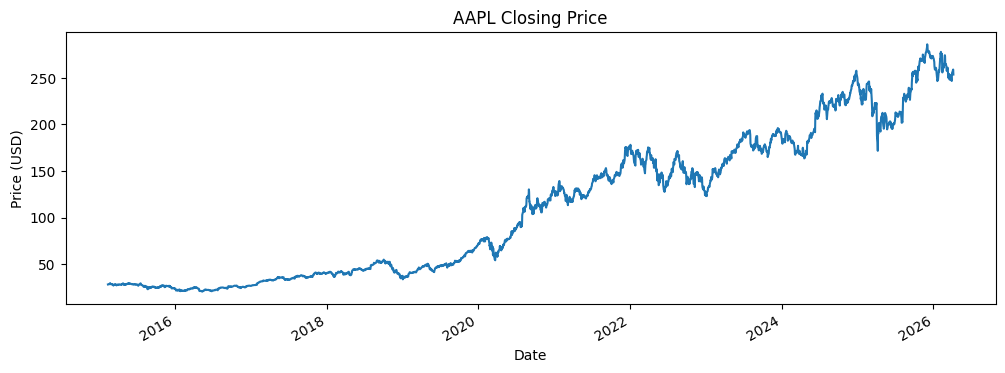

In [105]:
df["Close"].plot(title="AAPL Closing Price", figsize=(12, 4))
plt.ylabel("Price (USD)")
plt.show()

Normalize all features to a 0-1 range. Use a separate scaler for Close so we can inverse transform predictions later.

In [106]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

close_scaler = MinMaxScaler()
close_scaled = close_scaler.fit_transform(df[["Close"]])

print("Scaled shape:", scaled.shape)
print("First 2 rows:", scaled[:2])

Scaled shape: (2802, 5)
First 2 rows: [[0.02891603 0.31569756 0.02412241 0.01416532 0.47368842]
 [0.02954453 0.37199805 0.02508599 0.01471878 0.47723142]]


Create 60-day sequences for LSTM input. X uses all 5 features, y uses only Close price.

In [107]:
def create_sequences(X_data, y_data, window_size):
  X, y = [], []
  for i in range(window_size, len(X_data)):
    X.append(X_data[i-window_size:i])
    y.append(y_data[i])
  return np.array(X), np.array(y)

X, y = create_sequences(scaled, close_scaled, 60)
y = y.reshape(-1, 1)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2742, 60, 5)
y shape: (2742, 1)


Split into 80% train, 20% test - no shuffling since order matters for time series.

In [108]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2193, 60, 5) (2193, 1)
Test: (549, 60, 5) (549, 1)


Convert numpy arrays to PyTorch tensors and move to GPU.

In [109]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

print("Tensors moved to:", device)

Tensors moved to: cuda


Define the LSTM model - 2 LSTM layers with dropout, 5 input features.

In [110]:
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size=5, hidden_size=50, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(input_size=50, hidden_size=50, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x[:, -1, :])
        x = self.fc(x)
        return x

model = LSTMModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
print(model)

LSTMModel(
  (lstm1): LSTM(5, 50, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(50, 50, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


Train the model with early stopping - stops automatically when validation loss stops improving.

In [111]:
epochs = 100
patience = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_predictions = model(X_test_t)
        val_loss = criterion(val_predictions, y_test_t)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f} - Val Loss: {val_loss.item():.6f} - Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)
print("Best val loss:", best_val_loss.item())

Epoch 10/100 - Loss: 0.039640 - Val Loss: 0.181485 - Patience: 0/10
Epoch 20/100 - Loss: 0.023474 - Val Loss: 0.123916 - Patience: 0/10
Epoch 30/100 - Loss: 0.003005 - Val Loss: 0.023402 - Patience: 4/10

Early stopping at epoch 36
Best val loss: 0.0038845951203256845


Generate predictions and inverse transform back to real dollar values.

In [112]:
model.eval()
with torch.no_grad():
    predicted = model(X_test_t).cpu().numpy()
    actual = y_test_t.cpu().numpy()

predicted_prices = close_scaler.inverse_transform(predicted)
actual_prices = close_scaler.inverse_transform(actual)

print("Sample predictions:", predicted_prices[:5].flatten())
print("Sample actuals:", actual_prices[:5].flatten())

Sample predictions: [211.79303 212.1832  212.34772 212.25026 212.17436]
Sample actuals: [189.75867 186.10661 182.50403 184.93877 183.93916]


Plot predicted vs actual prices.

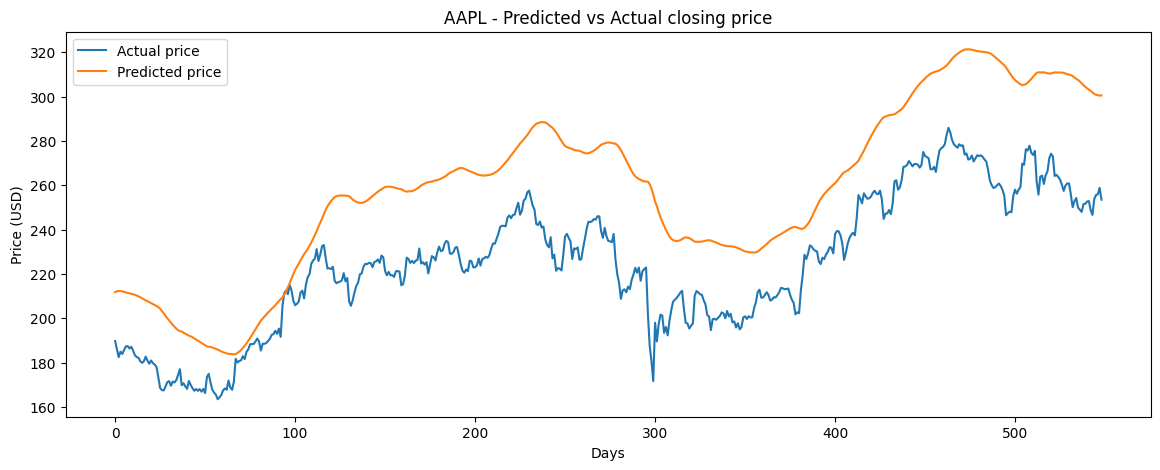

In [113]:
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label="Actual price")
plt.plot(predicted_prices, label="Predicted price")
plt.title("AAPL - Predicted vs Actual closing price")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

Calculate RMSE and directional accuracy.

In [114]:
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f"RMSE: ${rmse:.2f}")

signals = []
for i in range(1, len(predicted_prices)):
    if predicted_prices[i] > predicted_prices[i-1]:
        signals.append("UP")
    else:
        signals.append("DOWN")

up = signals.count("UP")
down = signals.count("DOWN")
print(f"UP signals: {up} ({up/len(signals)*100:.1f}%)")
print(f"DOWN signals: {down} ({down/len(signals)*100:.1f}%)")

RMSE: $36.22
UP signals: 298 (54.4%)
DOWN signals: 250 (45.6%)


7-day forecast using Monte Carlo Dropout for confidence intervals.

In [115]:
def forecast_7_days(model, last_sequence, close_scaler, n_simulations=100):
    model.train()
    all_forecasts = []

    for sim in range(n_simulations):
        forecast = []
        seq = last_sequence.copy()

        for day in range(7):
            input_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                pred = model(input_tensor).cpu().numpy()[0][0]
            forecast.append(pred)

            new_row = seq[-1].copy()
            new_row[0] = pred
            seq = np.vstack([seq[1:], new_row])

        all_forecasts.append(forecast)

    all_forecasts = np.array(all_forecasts)
    mean_forecast = all_forecasts.mean(axis=0)
    lower_bound = np.percentile(all_forecasts, 5, axis=0)
    upper_bound = np.percentile(all_forecasts, 95, axis=0)

    mean_prices = close_scaler.inverse_transform(mean_forecast.reshape(-1,1)).flatten()
    lower_prices = close_scaler.inverse_transform(lower_bound.reshape(-1,1)).flatten()
    upper_prices = close_scaler.inverse_transform(upper_bound.reshape(-1,1)).flatten()

    return mean_prices, lower_prices, upper_prices

last_sequence = scaled[-60:]
mean_prices, lower_prices, upper_prices = forecast_7_days(model, last_sequence, close_scaler)

print("7-day forecast:")
for i in range(7):
    print(f"Day {i+1}: ${mean_prices[i]:.2f} (${lower_prices[i]:.2f} - ${upper_prices[i]:.2f})")

7-day forecast:
Day 1: $302.75 ($262.84 - $337.49)
Day 2: $297.49 ($249.32 - $342.07)
Day 3: $302.45 ($255.81 - $341.40)
Day 4: $301.89 ($257.66 - $343.35)
Day 5: $303.44 ($260.87 - $340.45)
Day 6: $303.07 ($258.02 - $342.52)
Day 7: $304.64 ($265.16 - $342.16)


Visualize 7-day forecast with confidence intervals.

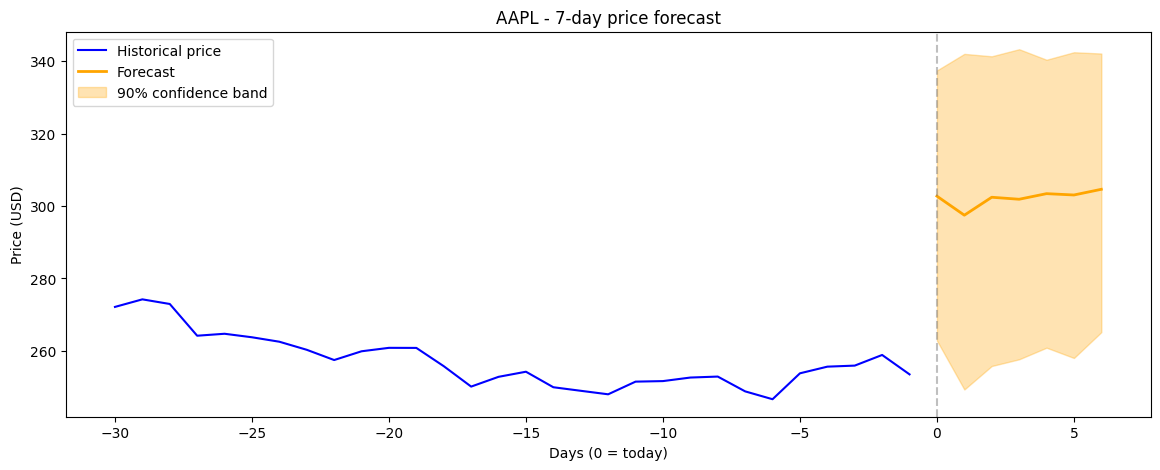

In [116]:
last_30_actual = close_scaler.inverse_transform(
    close_scaled[-30:]
).flatten()

plt.figure(figsize=(14, 5))
history_days = list(range(-30, 0))
forecast_days = list(range(0, 7))

plt.plot(history_days, last_30_actual,
         label="Historical price", color="blue")
plt.plot(forecast_days, mean_prices,
         label="Forecast", color="orange", linewidth=2)
plt.fill_between(forecast_days, lower_prices, upper_prices,
                 alpha=0.3, color="orange", label="90% confidence band")
plt.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
plt.title("AAPL - 7-day price forecast")
plt.xlabel("Days (0 = today)")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [ ]:
%%writefile app.py
import streamlit as st
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size=5, hidden_size=50, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(input_size=50, hidden_size=50, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x[:, -1, :])
        x = self.fc(x)
        return x

def create_sequences(X_data, y_data, window_size):
    X, y = [], []
    for i in range(window_size, len(X_data)):
        X.append(X_data[i-window_size:i])
        y.append(y_data[i])
    return np.array(X), np.array(y)

def forecast_7_days(model, last_sequence, close_scaler, n_simulations=100):
    model.train()
    all_forecasts = []
    for sim in range(n_simulations):
        forecast = []
        seq = last_sequence.copy()
        for day in range(7):
            input_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                pred = model(input_tensor).cpu().numpy()[0][0]
            forecast.append(pred)
            new_row = seq[-1].copy()
            new_row[0] = pred
            seq = np.vstack([seq[1:], new_row])
        all_forecasts.append(forecast)
    all_forecasts = np.array(all_forecasts)
    mean_forecast = all_forecasts.mean(axis=0)
    lower_bound = np.percentile(all_forecasts, 5, axis=0)
    upper_bound = np.percentile(all_forecasts, 95, axis=0)
    mean_prices = close_scaler.inverse_transform(mean_forecast.reshape(-1,1)).flatten()
    lower_prices = close_scaler.inverse_transform(lower_bound.reshape(-1,1)).flatten()
    upper_prices = close_scaler.inverse_transform(upper_bound.reshape(-1,1)).flatten()
    return mean_prices, lower_prices, upper_prices

@st.cache_resource
def train_model(ticker):
    data = yf.download(ticker, start="2015-01-01", end=pd.Timestamp.today().strftime("%Y-%m-%d"))
    df = data["Close"][ticker].to_frame(name="Close")
    df["Volume"] = data["Volume"][ticker]
    df["MA7"] = df["Close"].rolling(window=7).mean()
    df["MA30"] = df["Close"].rolling(window=30).mean()
    df["Return"] = df["Close"].pct_change()
    df = df.dropna()

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)
    close_scaler = MinMaxScaler()
    close_scaled = close_scaler.fit_transform(df[["Close"]])

    X, y = create_sequences(scaled, close_scaled, 60)
    y = y.reshape(-1, 1)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

    model = LSTMModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    epochs = 100
    patience = 10
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    progress = st.progress(0)
    status = st.empty()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions = model(X_train_t)
        loss = criterion(predictions, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(X_test_t)
            val_loss = criterion(val_predictions, y_test_t)

        progress.progress(min((epoch+1)/epochs, 1.0))
        status.text(f"Epoch {epoch+1} — Loss: {loss.item():.4f} — Val Loss: {val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        if patience_counter >= patience:
            status.text(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_state)
    progress.empty()

    model.eval()
    with torch.no_grad():
        predicted = model(X_test_t).cpu().numpy()
        actual = y_test_t.cpu().numpy()

    predicted_prices = close_scaler.inverse_transform(predicted)
    actual_prices = close_scaler.inverse_transform(actual)
    rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

    signals = []
    for i in range(1, len(predicted_prices)):
        if predicted_prices[i] > predicted_prices[i-1]:
            signals.append("UP")
        else:
            signals.append("DOWN")
    up_pct = signals.count("UP") / len(signals) * 100

    last_sequence = scaled[-60:]
    mean_prices, lower_prices, upper_prices = forecast_7_days(model, last_sequence, close_scaler)
    current_price = df["Close"].iloc[-1]
    close_scaled_full = close_scaler.transform(df[["Close"]])

    return {
        "predicted_prices": predicted_prices,
        "actual_prices": actual_prices,
        "rmse": rmse,
        "up_pct": up_pct,
        "mean_prices": mean_prices,
        "lower_prices": lower_prices,
        "upper_prices": upper_prices,
        "current_price": current_price,
        "close_scaled_full": close_scaled_full,
        "df": df
    }

st.title("Stock price predictor")
st.write("Enter a stock ticker and click predict to train an LSTM model and forecast the next 7 days.")

ticker = st.sidebar.text_input("Stock ticker", value="AAPL").upper()
predict_button = st.sidebar.button("Predict")

if predict_button:
    with st.spinner(f"Downloading data and training model for {ticker}..."):
        results = train_model(ticker)

    current = results["current_price"]
    forecast_day1 = results["mean_prices"][0]
    direction = "UP" if forecast_day1 > current else "DOWN"
    direction_pct = abs((forecast_day1 - current) / current * 100)

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Current price", f"${current:.2f}")
    col2.metric("Day 1 forecast", f"${forecast_day1:.2f}", f"{direction} {direction_pct:.1f}%")
    col3.metric("RMSE", f"${results['rmse']:.2f}")
    col4.metric("Directional accuracy", f"{results['up_pct']:.1f}%")

    st.subheader("Predicted vs actual price")
    fig1, ax1 = plt.subplots(figsize=(14, 4))
    ax1.plot(results["actual_prices"], label="Actual price")
    ax1.plot(results["predicted_prices"], label="Predicted price")
    ax1.set_xlabel("Days")
    ax1.set_ylabel("Price (USD)")
    ax1.legend()
    st.pyplot(fig1)

    st.subheader("7-day forecast")
    last_30 = close_scaler = MinMaxScaler()
    last_30_prices = results["df"]["Close"].iloc[-30:].values
    fig2, ax2 = plt.subplots(figsize=(14, 4))
    ax2.plot(range(-30, 0), last_30_prices, label="Historical price", color="blue")
    ax2.plot(range(0, 7), results["mean_prices"], label="Forecast", color="orange", linewidth=2)
    ax2.fill_between(range(0, 7), results["lower_prices"], results["upper_prices"],
                     alpha=0.3, color="orange", label="90% confidence band")
    ax2.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
    ax2.set_xlabel("Days (0 = today)")
    ax2.set_ylabel("Price (USD)")
    ax2.legend()
    st.pyplot(fig2)

    st.subheader("7-day forecast table")
    forecast_df = pd.DataFrame({
        "Day": [f"Day {i+1}" for i in range(7)],
        "Forecast": [f"${p:.2f}" for p in results["mean_prices"]],
        "Low (5%)": [f"${p:.2f}" for p in results["lower_prices"]],
        "High (95%)": [f"${p:.2f}" for p in results["upper_prices"]],
        "Signal": ["UP" if results["mean_prices"][i] > results["mean_prices"][i-1]
                   else "DOWN" for i in range(7)]
    })
    st.dataframe(forecast_df, use_container_width=True)

Writing app.py
